In [1]:
import pandas as pd 
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("Train.csv")

In [3]:
df.head()

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


In [4]:
df.dtypes

ID                      int64
Warehouse_block        object
Mode_of_Shipment       object
Customer_care_calls     int64
Customer_rating         int64
Cost_of_the_Product     int64
Prior_purchases         int64
Product_importance     object
Gender                 object
Discount_offered        int64
Weight_in_gms           int64
Reached.on.Time_Y.N     int64
dtype: object

In [5]:
df.isnull().sum()

ID                     0
Warehouse_block        0
Mode_of_Shipment       0
Customer_care_calls    0
Customer_rating        0
Cost_of_the_Product    0
Prior_purchases        0
Product_importance     0
Gender                 0
Discount_offered       0
Weight_in_gms          0
Reached.on.Time_Y.N    0
dtype: int64

In [6]:
df.describe()

,ID,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
count,10999.00000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000
mean,5500.00000,4.054459,2.990545,210.196836,3.567597,13.373216,3634.016729,0.596691
std,3175.28214,1.141490,1.413603,48.063272,1.522860,16.205527,1635.377251,0.490584
min,1.00000,2.000000,1.000000,96.000000,2.000000,1.000000,1001.000000,0.000000
25%,2750.50000,3.000000,2.000000,169.000000,3.000000,4.000000,1839.500000,0.000000
50%,5500.00000,4.000000,3.000000,214.000000,3.000000,7.000000,4149.000000,1.000000
75%,8249.50000,5.000000,4.000000,251.000000,4.000000,10.000000,5050.000000,1.000000
max,10999.00000,7.000000,5.000000,310.000000,10.000000,65.000000,7846.000000,1.000000


In [7]:
df.shape

(10999, 12)

In [8]:
df.iloc[0]

ID                          1
Warehouse_block             D
Mode_of_Shipment       Flight
Customer_care_calls         4
Customer_rating             2
Cost_of_the_Product       177
Prior_purchases             3
Product_importance        low
Gender                      F
Discount_offered           44
Weight_in_gms            1233
Reached.on.Time_Y.N         1
Name: 0, dtype: object

In [9]:
#Sort values by ID
df.sort_values(by="ID",ascending=True)
df.sort_index()

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1
...,...,...,...,...,...,...,...,...,...,...,...,...
10994,10995,A,Ship,4,1,252,5,medium,F,1,1538,1
10995,10996,B,Ship,4,1,232,5,medium,F,6,1247,0
10996,10997,C,Ship,5,4,242,5,low,F,4,1155,0
10997,10998,F,Ship,5,2,223,6,medium,M,2,1210,0


In [10]:
#GroupBy Warehouse_block & Customer_rating
df.groupby("Warehouse_block")["Customer_rating"].mean()

Warehouse_block
A    2.957447
B    2.980360
C    2.993999
D    3.017993
F    2.996727
Name: Customer_rating, dtype: float64

In [11]:
df.groupby(["Warehouse_block","Cost_of_the_Product"])["Customer_rating"].sum()

Warehouse_block  Cost_of_the_Product
A                96                      4
                 97                      4
                 98                     19
                 99                      5
                 100                     7
                                        ..
F                306                    25
                 307                    12
                 308                    23
                 309                     7
                 310                    20
Name: Customer_rating, Length: 1032, dtype: int64

In [12]:
# select specific columns 
df[['ID', 'Cost_of_the_Product']]

,ID,Cost_of_the_Product
0,1,177
1,2,216
2,3,183
3,4,176
4,5,184
...,...,...
10994,10995,252
10995,10996,232
10996,10997,242
10997,10998,223


In [13]:
#Filter Values Where cuatomer rating > 3 and mode of shipment is Flight
df[(df['Customer_rating'] > 3) & (df['Mode_of_Shipment'] == 'Flight')]

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
6,7,D,Flight,3,4,250,3,low,F,3,2371,1
8,9,A,Flight,3,4,150,3,low,F,11,1861,1
10,11,C,Flight,3,4,189,2,medium,M,12,2888,1
11,12,F,Flight,4,5,232,3,medium,F,32,3253,1
...,...,...,...,...,...,...,...,...,...,...,...,...
10966,10967,C,Flight,5,5,246,5,low,F,6,1300,0
10967,10968,F,Flight,5,4,221,6,medium,M,5,1944,0
10968,10969,D,Flight,4,4,257,5,medium,F,4,1668,0
10970,10971,A,Flight,4,4,216,6,low,M,5,1272,0


In [14]:
#isin()
df[df['Warehouse_block'].isin(['A','B'])]

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
8,9,A,Flight,3,4,150,3,low,F,11,1861,1
9,10,B,Flight,3,2,164,3,medium,F,29,1187,1
14,15,A,Flight,4,3,152,3,low,M,43,1009,1
...,...,...,...,...,...,...,...,...,...,...,...,...
10983,10984,B,Ship,4,3,229,6,medium,M,1,1235,1
10988,10989,A,Ship,4,3,192,4,low,F,2,1830,0
10989,10990,B,Ship,5,1,218,5,medium,F,9,1603,0
10994,10995,A,Ship,4,1,252,5,medium,F,1,1538,1


In [15]:
df['Mode_of_Shipment'].unique()  #distinct mode of shipment

array(['Flight', 'Ship', 'Road'], dtype=object)

In [16]:
#count of unique product importance
df['Product_importance'].value_counts()

Product_importance
low       5297
medium    4754
high       948
Name: count, dtype: int64

In [17]:
#Sum() - sum of cost of all products 
df['Cost_of_the_Product'].sum()

np.int64(2311955)

In [18]:
#number of unique warehouse blocks
df['Warehouse_block'].nunique()

5

In [19]:
#Groupby 
df.groupby("Product_importance")["Cost_of_the_Product"].median()

Product_importance
high      205.5
low       218.0
medium    213.0
Name: Cost_of_the_Product, dtype: float64

In [20]:
df[df['Customer_rating']>3]['Customer_rating'].value_counts()

Customer_rating
4    2189
5    2171
Name: count, dtype: int64

In [21]:
#LIKE (string contains)
df[df['Mode_of_Shipment'].str.contains('Ship')]

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
17,18,F,Ship,5,5,227,3,medium,M,36,3952,1
18,19,D,Ship,5,5,239,3,high,M,18,2495,1
19,20,F,Ship,4,5,145,3,medium,M,45,1059,1
20,21,A,Ship,3,3,161,2,medium,F,38,1521,1
21,22,B,Ship,3,1,232,4,medium,F,51,2899,1
...,...,...,...,...,...,...,...,...,...,...,...,...
10994,10995,A,Ship,4,1,252,5,medium,F,1,1538,1
10995,10996,B,Ship,4,1,232,5,medium,F,6,1247,0
10996,10997,C,Ship,5,4,242,5,low,F,4,1155,0
10997,10998,F,Ship,5,2,223,6,medium,M,2,1210,0


In [22]:
#map()-mapping the floating number to each element
numbers=[1,2,3,4,5]
list(map(float,numbers))

[1.0, 2.0, 3.0, 4.0, 5.0]

In [23]:
#filter()

In [24]:
numbers = [1,2,4,7,3,50,200]

number_greater_50=list(filter(lambda x:x>50,numbers))

print(number_greater_50)

[200]


In [25]:
#map
number_greater = list(map(lambda x:x>50,numbers))

In [26]:
number_greater

[False, False, False, False, False, False, True]

In [27]:
'''lambda → defines what the function does.

map → where and how to apply that function on a collection.'''

'lambda → defines what the function does.\n\nmap → where and how to apply that function on a collection.'

In [28]:
# regex: helps in filtering / like searching 

In [29]:
df.filter(regex = "C")

,Customer_care_calls,Customer_rating,Cost_of_the_Product
0,4,2,177
1,4,5,216
2,2,2,183
3,3,3,176
4,2,2,184
...,...,...,...
10994,4,1,252
10995,4,1,232
10996,5,4,242
10997,5,2,223


In [30]:
df.filter(regex = "rating")

,Customer_rating
0,2
1,5
2,2
3,3
4,2
...,...
10994,1
10995,1
10996,4
10997,2


In [31]:
#like()
df.filter(like='rating')

,Customer_rating
0,2
1,5
2,2
3,3
4,2
...,...
10994,1
10995,1
10996,4
10997,2


In [32]:
df.iloc[100:,:]

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
100,101,C,Ship,5,3,143,2,medium,M,59,1837,1
101,102,F,Ship,5,5,227,4,low,M,53,2624,1
102,103,D,Ship,2,1,213,3,low,M,29,2732,1
103,104,F,Ship,5,1,144,4,low,M,37,1658,1
104,105,A,Ship,3,3,218,3,low,M,3,2255,1
...,...,...,...,...,...,...,...,...,...,...,...,...
10994,10995,A,Ship,4,1,252,5,medium,F,1,1538,1
10995,10996,B,Ship,4,1,232,5,medium,F,6,1247,0
10996,10997,C,Ship,5,4,242,5,low,F,4,1155,0
10997,10998,F,Ship,5,2,223,6,medium,M,2,1210,0


In [33]:
#str.contains()

df[df['Mode_of_Shipment'].str.contains('hi')]

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
17,18,F,Ship,5,5,227,3,medium,M,36,3952,1
18,19,D,Ship,5,5,239,3,high,M,18,2495,1
19,20,F,Ship,4,5,145,3,medium,M,45,1059,1
20,21,A,Ship,3,3,161,2,medium,F,38,1521,1
21,22,B,Ship,3,1,232,4,medium,F,51,2899,1
...,...,...,...,...,...,...,...,...,...,...,...,...
10994,10995,A,Ship,4,1,252,5,medium,F,1,1538,1
10995,10996,B,Ship,4,1,232,5,medium,F,6,1247,0
10996,10997,C,Ship,5,4,242,5,low,F,4,1155,0
10997,10998,F,Ship,5,2,223,6,medium,M,2,1210,0


In [34]:
#in 
"t" in "infosys"

False

In [35]:
"S" in "Sanika"

True

In [36]:
#created a new column Date_Delivery using date_range()
dates=pd.date_range(start="2025-08-29 00:00",periods=10999,freq="h")
df["Date_Delivery"]=dates

In [37]:
df["Date_Delivery"]

0       2025-08-29 00:00:00
1       2025-08-29 01:00:00
2       2025-08-29 02:00:00
3       2025-08-29 03:00:00
4       2025-08-29 04:00:00
                ...        
10994   2026-11-30 02:00:00
10995   2026-11-30 03:00:00
10996   2026-11-30 04:00:00
10997   2026-11-30 05:00:00
10998   2026-11-30 06:00:00
Name: Date_Delivery, Length: 10999, dtype: datetime64[ns]

In [38]:
#lambda() and capitalize()
words=['apple','banana']
capitalised = list(map(lambda w:w.capitalize(),words))
capitalised

['Apple', 'Banana']

In [39]:
df['Cost_of_the_Product-temp']=df['Cost_of_the_Product'].apply(lambda x:x*2)

In [40]:
df[['Cost_of_the_Product','Cost_of_the_Product-temp']]

,Cost_of_the_Product,Cost_of_the_Product-temp
0,177,354
1,216,432
2,183,366
3,176,352
4,184,368
...,...,...
10994,252,504
10995,232,464
10996,242,484
10997,223,446


In [41]:
#loc()
df.loc[100,['ID','Cost_of_the_Product']]

ID                     101
Cost_of_the_Product    143
Name: 100, dtype: object

In [42]:
df.iloc[1:3:5]

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N,Date_Delivery,Cost_of_the_Product-temp
1,2,F,Flight,4,5,216,2,low,M,59,3088,1,2025-08-29 01:00:00,432


In [43]:
add_5=lambda x,y : x+y+5
print(add_5(3,5))

13


In [44]:
#Queries 
# 1. Get 3  cheapest products with their weights.
cheapest=df[['Cost_of_the_Product','Weight_in_gms']].nsmallest(3,'Cost_of_the_Product').reset_index(drop=True)
print(cheapest)

   Cost_of_the_Product  Weight_in_gms
0                   96           1294
1                   96           1655
2                   96           1186


In [45]:
# 2. Average customer care calls
avg_calls= df['Customer_care_calls'].mean()
print(avg_calls)

4.054459496317847


In [46]:
# 3. Highest customer rating
max_rating=df['Customer_rating'].max()
print(max_rating)

5


In [47]:
# 4. products delivered on time
on_time=df[df['Reached.on.Time_Y.N']==1]
print(on_time.shape[0])

6563


In [48]:
# 5.Most frequent product importance level

importance_counts=df['Product_importance'].value_counts()
print(importance_counts)

Product_importance
low       5297
medium    4754
high       948
Name: count, dtype: int64


In [49]:
# 6.Total discount offered by gender
discount_by_gender = df.groupby('Gender')['Discount_offered'].sum()
print(discount_by_gender)

Gender
F    75204
M    71888
Name: Discount_offered, dtype: int64


In [50]:
# 7. Mode of Shipment Distribution
shipment_mode = df['Mode_of_Shipment'].value_counts()
print(shipment_mode)

Mode_of_Shipment
Ship      7462
Flight    1777
Road      1760
Name: count, dtype: int64


In [51]:
# 9. Correlation between cost and weight

correlation = df['Cost_of_the_Product'].corr(df['Weight_in_gms'])
print(correlation)

-0.13260404754942498


In [52]:
# 10.Use lambda with apply → Create a new column for cost category

df['Cost_Category'] = df['Cost_of_the_Product'].apply(lambda x: 'High' if x > 200 else 'Low')
print(df[['Cost_of_the_Product','Cost_Category']])

       Cost_of_the_Product Cost_Category
0                      177           Low
1                      216          High
2                      183           Low
3                      176           Low
4                      184           Low
...                    ...           ...
10994                  252          High
10995                  232          High
10996                  242          High
10997                  223          High
10998                  155           Low

[10999 rows x 2 columns]


In [53]:
# 11.Use map → Convert Gender values to full form
df['Gender_Full'] = df['Gender'].map({'M':'Male','F':'Female'})
print(df[['Gender','Gender_Full']])

      Gender Gender_Full
0          F      Female
1          M        Male
2          M        Male
3          M        Male
4          F      Female
...      ...         ...
10994      F      Female
10995      F      Female
10996      F      Female
10997      M        Male
10998      F      Female

[10999 rows x 2 columns]


In [54]:
#Converts raw discounts into percentage values.
df['Discount_percent'] = df['Discount_offered'].apply(lambda x: (x/100))
print(df[['Discount_offered','Discount_percent']])

       Discount_offered  Discount_percent
0                    44              0.44
1                    59              0.59
2                    48              0.48
3                    10              0.10
4                    46              0.46
...                 ...               ...
10994                 1              0.01
10995                 6              0.06
10996                 4              0.04
10997                 2              0.02
10998                 6              0.06

[10999 rows x 2 columns]


In [55]:
df.shape

(10999, 17)

In [56]:
# Assume missing ratings are filled with average
df['Customer_rating'] = df['Customer_rating'].fillna(df['Customer_rating'].mean())

In [57]:
#astype() → Change datatype
# df['Customer_care_calls'] = df['Customer_care_calls'].astype(float)
#print(df.dtypes)

In [58]:
#pivote table 
#Example 1: Average product cost per shipment mode

pivot1 = df.pivot_table(
    values='Cost_of_the_Product',
    index='Mode_of_Shipment',
    aggfunc='mean'
)
print(pivot1)

#This will show the average Cost_of_the_Product for each Mode_of_Shipment (e.g., Flight, Ship, Road, etc.).
#Pivot tables in Pandas are super useful when you want to summarize data (like SQL GROUP BY) and get meaningful insights.

                  Cost_of_the_Product
Mode_of_Shipment                     
Flight                     209.306697
Road                       210.475568
Ship                       210.343072


In [59]:
# important features present in our dataset
'''Mode_of_Shipment

Customer_care_calls

Discount_offered

Weight_in_gms

Customer_rating

Product_importance'''

'Mode_of_Shipment\n\nCustomer_care_calls\n\nDiscount_offered\n\nWeight_in_gms\n\nCustomer_rating\n\nProduct_importance'

In [60]:
#features that we can create 
# 1. Total Cost after Discount

df['Final_Price'] = df['Cost_of_the_Product'] - df['Discount_offered']
print(df[['Cost_of_the_Product', 'Discount_offered', 'Final_Price']].head())

   Cost_of_the_Product  Discount_offered  Final_Price
0                  177                44          133
1                  216                59          157
2                  183                48          135
3                  176                10          166
4                  184                46          138


In [61]:
#Customer Satisfaction Flag
df['Satisfied_Customer'] = df['Customer_rating'].apply(lambda x: 1 if x >= 4 else 0)
print(df[['Customer_rating','Satisfied_Customer']].head())
#New binary column: 1 = satisfied, 0 = not.

   Customer_rating  Satisfied_Customer
0                2                   0
1                5                   1
2                2                   0
3                3                   0
4                2                   0


In [62]:
#discount percentages
#Helps to analyze whether higher discounts lead to better delivery or satisfaction.

df['Discount_Percent'] = (df['Discount_offered'] / df['Cost_of_the_Product']) * 100
print(df[['Cost_of_the_Product','Discount_offered','Discount_Percent']].head())

   Cost_of_the_Product  Discount_offered  Discount_Percent
0                  177                44         24.858757
1                  216                59         27.314815
2                  183                48         26.229508
3                  176                10          5.681818
4                  184                46         25.000000


In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

In [64]:
df.describe()         # Statistical summary (mean, std, quartiles)

,ID,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N,Date_Delivery,Cost_of_the_Product-temp,Discount_percent,Final_Price,Satisfied_Customer,Discount_Percent
count,10999.00000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000
mean,5500.00000,4.054459,2.990545,210.196836,3.567597,13.373216,3634.016729,0.596691,2026-04-15 03:00:00,420.393672,0.133732,196.823620,0.396400,7.023666
min,1.00000,2.000000,1.000000,96.000000,2.000000,1.000000,1001.000000,0.000000,2025-08-29 00:00:00,192.000000,0.010000,36.000000,0.000000,0.322581
25%,2750.50000,3.000000,2.000000,169.000000,3.000000,4.000000,1839.500000,0.000000,2025-12-21 13:30:00,338.000000,0.040000,155.000000,0.000000,1.754386
50%,5500.00000,4.000000,3.000000,214.000000,3.000000,7.000000,4149.000000,1.000000,2026-04-15 03:00:00,428.000000,0.070000,200.000000,0.000000,3.333333
75%,8249.50000,5.000000,4.000000,251.000000,4.000000,10.000000,5050.000000,1.000000,2026-08-07 16:30:00,502.000000,0.100000,241.000000,1.000000,6.296459
max,10999.00000,7.000000,5.000000,310.000000,10.000000,65.000000,7846.000000,1.000000,2026-11-30 06:00:00,620.000000,0.650000,309.000000,1.000000,63.636364
std,3175.28214,1.141490,1.413603,48.063272,1.522860,16.205527,1635.377251,0.490584,NaN,96.126544,0.162055,52.802998,0.489171,9.268773


<Axes: xlabel='Cost_of_the_Product', ylabel='Count'>

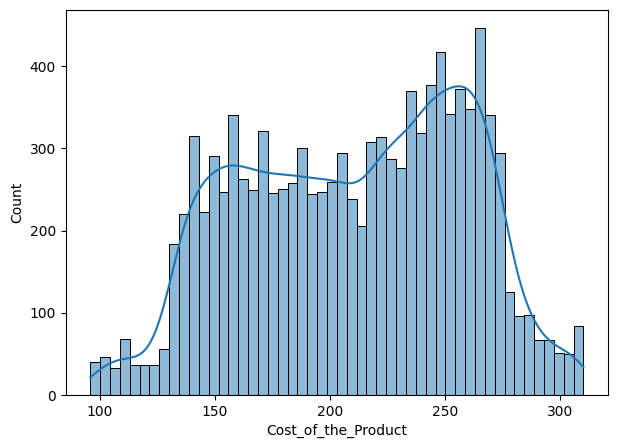

In [65]:
plt.figure(figsize=(7,5))
sns.histplot(df['Cost_of_the_Product'],bins=50,kde=True) #
# Interpretation: See if product cost follows normal or skewed distribution

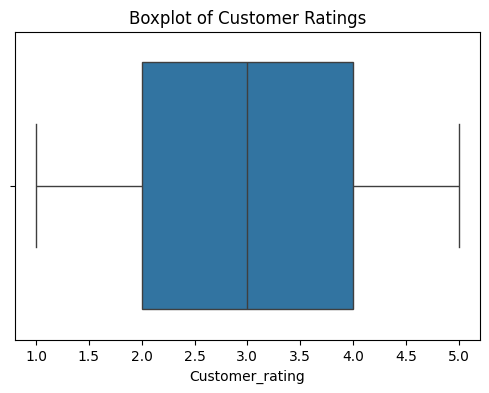

In [66]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["Customer_rating"])
plt.title("Boxplot of Customer Ratings")
plt.show()
# Interpretation: Boxplot helps detect outliers in customer ratings

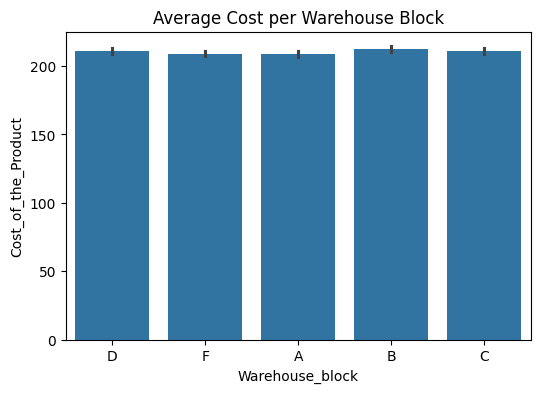

In [67]:
plt.figure(figsize=(6,4))
sns.barplot(x="Warehouse_block", y="Cost_of_the_Product", data=df)
plt.title("Average Cost per Warehouse Block")
plt.show()
# Interpretation: Compares avg. product cost across warehouses

<Axes: xlabel='Mode_of_Shipment', ylabel='count'>

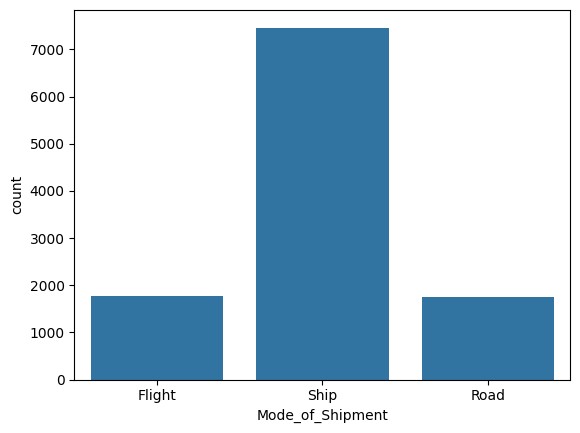

In [68]:
sns.countplot(x='Mode_of_Shipment',data=df)

<Axes: xlabel='Cost_of_the_Product'>

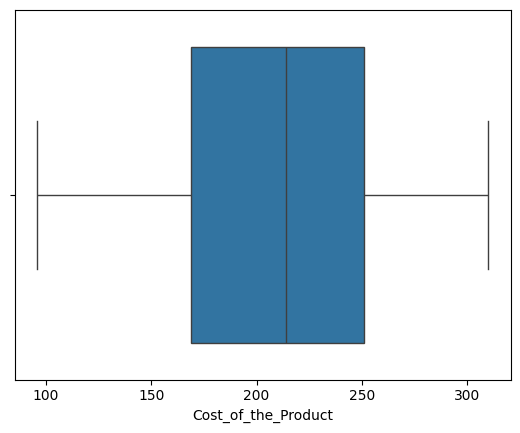

In [69]:
sns.boxplot(x='Cost_of_the_Product',data=df)


<Axes: xlabel='Warehouse_block', ylabel='Customer_care_calls'>

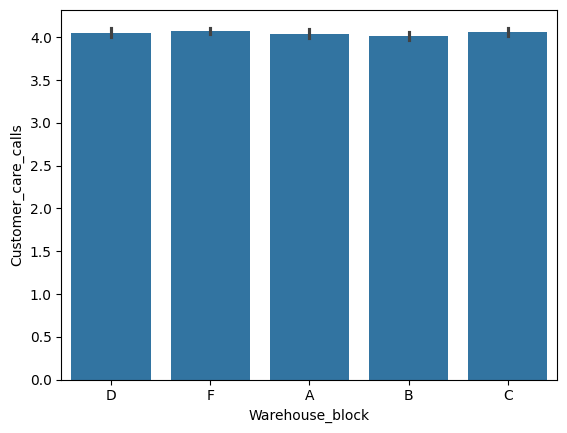

In [70]:
sns.barplot(x = 'Warehouse_block', y = 'Customer_care_calls', data = df)

<Axes: xlabel='Cost_of_the_Product'>

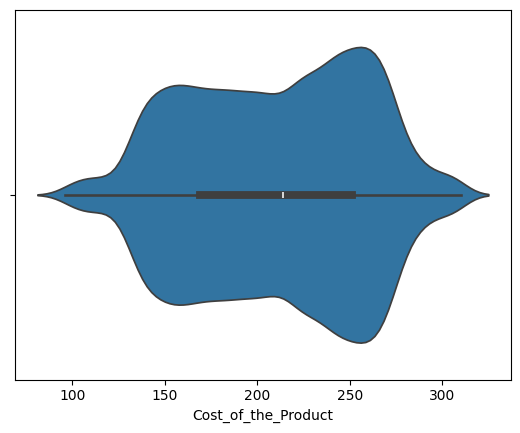

In [71]:
sns.violinplot(x='Cost_of_the_Product',data=df)

<Axes: xlabel='Prior_purchases', ylabel='Cost_of_the_Product'>

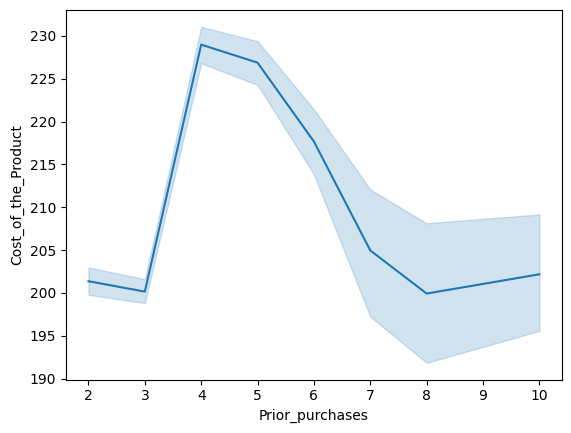

In [72]:
sns.lineplot(x='Prior_purchases',y='Cost_of_the_Product',data=df)

<Axes: xlabel='Cost_of_the_Product', ylabel='Weight_in_gms'>

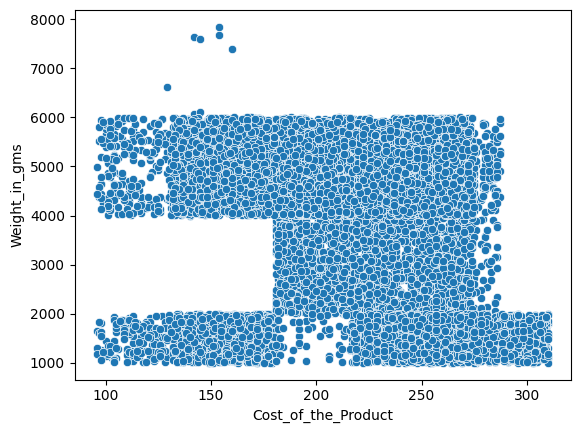

In [73]:
#RELATIONSHIPS BETWEEN VARIABLES
sns.scatterplot(x='Cost_of_the_Product',y='Weight_in_gms',data=df)

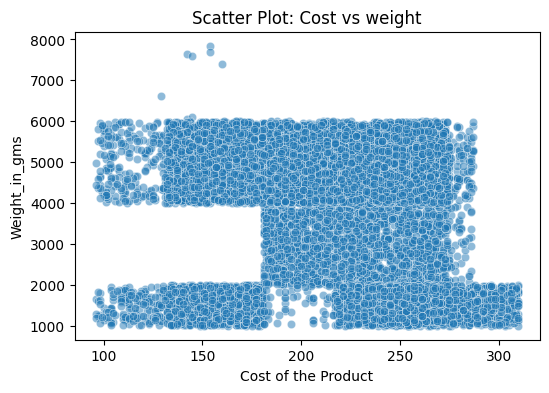

In [74]:
plt.figure(figsize=(6,4))
sns.scatterplot(
    x="Cost_of_the_Product", 
    y="Weight_in_gms", 
    data=df,
    alpha=0.5   # transparency (0 = fully transparent, 1 = solid)
)
plt.title("Scatter Plot: Cost vs weight")
plt.xlabel("Cost of the Product")
plt.ylabel("Weight_in_gms")
plt.show()

#Without alpha: all points look the same color, and dense areas aren’t obvious.
#With alpha < 1: overlapping areas become darker, showing where more points are concentrated.

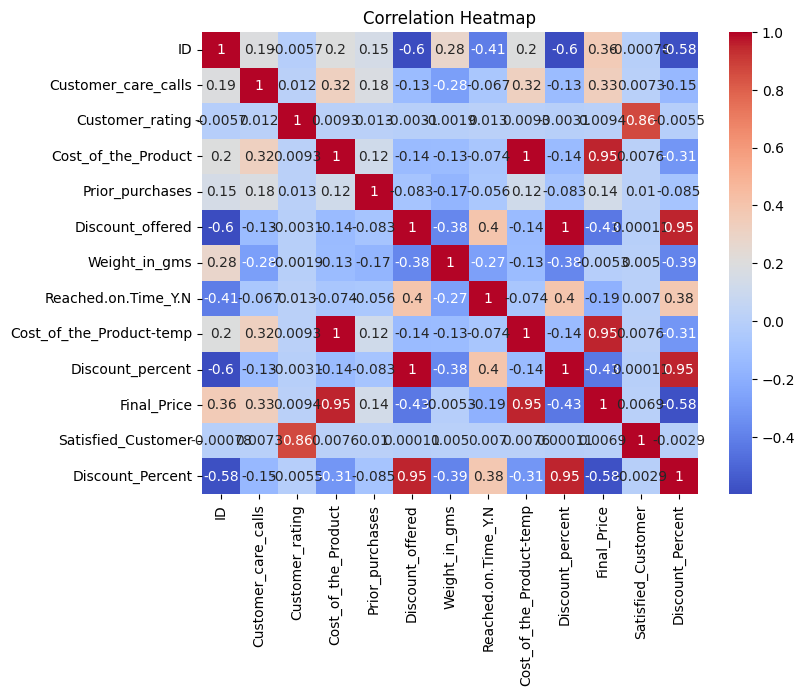

In [75]:
# CORRELATION HEATMAP
# -------------------------------
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()
# Interpretation: Look for strong correlations (close to +1 or -1) between numerical columns

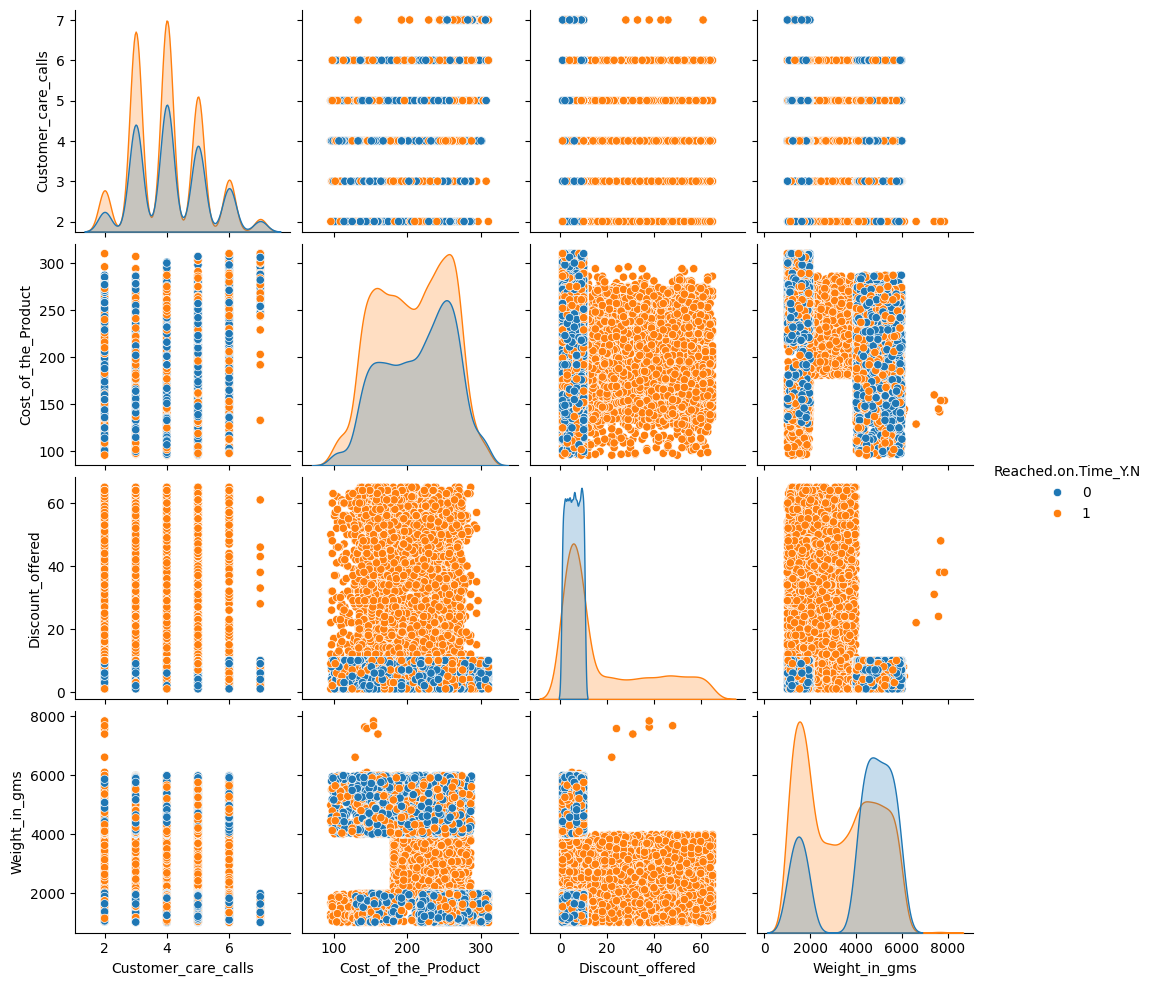

In [76]:
num_cols=['Customer_care_calls','Cost_of_the_Product','Discount_offered','Weight_in_gms','Reached.on.Time_Y.N']
sns.pairplot(df[num_cols],
             hue= 'Reached.on.Time_Y.N')

In [77]:
df.isnull().sum()

ID                          0
Warehouse_block             0
Mode_of_Shipment            0
Customer_care_calls         0
Customer_rating             0
Cost_of_the_Product         0
Prior_purchases             0
Product_importance          0
Gender                      0
Discount_offered            0
Weight_in_gms               0
Reached.on.Time_Y.N         0
Date_Delivery               0
Cost_of_the_Product-temp    0
Cost_Category               0
Gender_Full                 0
Discount_percent            0
Final_Price                 0
Satisfied_Customer          0
Discount_Percent            0
dtype: int64

In [78]:
df.shape

(10999, 20)

# Feature Engineering - creating new featurs from the dataset

In [79]:
#Cost per Gram → captures how expensive a product is relative to its weight.
df['Cost_per_grams']=df['Cost_of_the_Product']/df['Weight_in_gms']

In [80]:
# Discounted Price → effective price after discount.
df['Discounted_Price'] = df['Cost_of_the_Product'] - df['Discount_offered']

In [81]:
# Discount Percentage → shows how big the discount is.
df['Discount_Percentage'] = (df['Discount_offered'] / df['Cost_of_the_Product']) * 100

In [82]:
# High Weight Flag → to capture heavy parcels.
df['Heavy_Shipment'] = (df['Weight_in_gms'] > 2500).astype(int)

In [83]:
# High Discount Flag → to check if discounts affect delays.
df['High_Discount'] = (df['Discount_offered'] > 30).astype(int)

In [84]:
df.head()

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,...,Gender_Full,Discount_percent,Final_Price,Satisfied_Customer,Discount_Percent,Cost_per_grams,Discounted_Price,Discount_Percentage,Heavy_Shipment,High_Discount
0,1,D,Flight,4,2,177,3,low,F,44,...,Female,0.44,133,0,24.858757,0.143552,133,24.858757,0,1
1,2,F,Flight,4,5,216,2,low,M,59,...,Male,0.59,157,1,27.314815,0.069948,157,27.314815,1,1
2,3,A,Flight,2,2,183,4,low,M,48,...,Male,0.48,135,0,26.229508,0.054238,135,26.229508,1,1
3,4,B,Flight,3,3,176,4,medium,M,10,...,Male,0.10,166,0,5.681818,0.149533,166,5.681818,0,0
4,5,C,Flight,2,2,184,3,medium,F,46,...,Female,0.46,138,0,25.000000,0.074074,138,25.000000,0,1


In [85]:
df.shape

(10999, 25)

# Imputation

In [86]:
import pandas as pd
import numpy as np

# Create sample data
data = {
    'Age': [25, 30, np.nan, 40, 35, np.nan, 28],
    'Salary': [50000, 60000, 55000, np.nan, 65000, 70000, np.nan],
    'Department': ['HR', 'IT', 'Finance', np.nan, 'Finance', 'IT', 'HR']
}

df2 = pd.DataFrame(data)
print("Original Dataset with Missing Values:\n")
print(df2)

Original Dataset with Missing Values:

    Age   Salary Department
0  25.0  50000.0         HR
1  30.0  60000.0         IT
2   NaN  55000.0    Finance
3  40.0      NaN        NaN
4  35.0  65000.0    Finance
5   NaN  70000.0         IT
6  28.0      NaN         HR


In [87]:
print("\nMissing Values Count:\n")
print(df2.isnull().sum())


Missing Values Count:

Age           2
Salary        2
Department    1
dtype: int64


In [88]:
# 1. Mean Imputation (for Age)
df2['Age_mean'] = df2['Age'].fillna(df2['Age'].mean())
print("\nAfter Mean Imputation (Age):\n", df2[['Age', 'Age_mean']])

# 2. Median Imputation (for Age)
df2['Age_median'] = df2['Age'].fillna(df2['Age'].median())
print("\nAfter Median Imputation (Age):\n", df2[['Age', 'Age_median']])

# 3. Mode Imputation (for Department)
df2['Department_mode'] = df2['Department'].fillna(df2['Department'].mode()[0])
print("\nAfter Mode Imputation (Department):\n", df2[['Department', 'Department_mode']])


After Mean Imputation (Age):
     Age  Age_mean
0  25.0      25.0
1  30.0      30.0
2   NaN      31.6
3  40.0      40.0
4  35.0      35.0
5   NaN      31.6
6  28.0      28.0

After Median Imputation (Age):
     Age  Age_median
0  25.0        25.0
1  30.0        30.0
2   NaN        30.0
3  40.0        40.0
4  35.0        35.0
5   NaN        30.0
6  28.0        28.0

After Mode Imputation (Department):
   Department Department_mode
0         HR              HR
1         IT              IT
2    Finance         Finance
3        NaN         Finance
4    Finance         Finance
5         IT              IT
6         HR              HR


In [89]:
# 4. Forward Fill (for Salary)
df2['Salary_ffill'] = df2['Salary'].fillna(method='ffill')
print("\nAfter Forward Fill (Salary):\n", df2[['Salary', 'Salary_ffill']])

# 5. Backward Fill (for Salary)
df2['Salary_bfill'] = df2['Salary'].fillna(method='bfill')
print("\nAfter Backward Fill (Salary):\n", df2[['Salary', 'Salary_bfill']])


After Forward Fill (Salary):
     Salary  Salary_ffill
0  50000.0       50000.0
1  60000.0       60000.0
2  55000.0       55000.0
3      NaN       55000.0
4  65000.0       65000.0
5  70000.0       70000.0
6      NaN       70000.0

After Backward Fill (Salary):
     Salary  Salary_bfill
0  50000.0       50000.0
1  60000.0       60000.0
2  55000.0       55000.0
3      NaN       65000.0
4  65000.0       65000.0
5  70000.0       70000.0
6      NaN           NaN


C:\Users\Admin\AppData\Local\Temp\ipykernel_23320\1608552588.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df2['Salary_ffill'] = df2['Salary'].fillna(method='ffill')
C:\Users\Admin\AppData\Local\Temp\ipykernel_23320\1608552588.py:6: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df2['Salary_bfill'] = df2['Salary'].fillna(method='bfill')


In [91]:
from sklearn.impute import SimpleImputer
# 6. SimpleImputer (mean strategy for Salary)

#The SimpleImputer is a preprocessing tool in sklearn.impute used to handle missing values in a dataset.

imputer_mean = SimpleImputer(strategy='mean')
df2['Salary_imputed'] = imputer_mean.fit_transform(df2[['Salary']])
print("\nAfter SimpleImputer Mean (Salary):\n", df2[['Salary', 'Salary_imputed']])


After SimpleImputer Mean (Salary):
     Salary  Salary_imputed
0  50000.0         50000.0
1  60000.0         60000.0
2  55000.0         55000.0
3      NaN         60000.0
4  65000.0         65000.0
5  70000.0         70000.0
6      NaN         60000.0


In [ ]:
# interpolation : Interpolation is the process of estimating an unknown data point that falls between two or more known data points, creating a new point within the existing range of data

In [92]:
# Linear, Polynomial, and Spline Interpolation Example

import pandas as pd
import numpy as np

# Sample dataset with missing values
data = {
    'Day': [1, 2, 3, 4, 5, 6, 7],
    'Temperature': [30, np.nan, 32, np.nan, 35, 36, np.nan]
}

df_interpolation = pd.DataFrame(data)
print("Before Interpolation:\n", df_interpolation)

#  Linear Interpolation
df_interpolation['Temperature_linear'] = df_interpolation['Temperature'].interpolate(method='linear')
print("\nAfter Linear Interpolation:\n", df_interpolation)

# Polynomial Interpolation (order 2 = quadratic curve)
df_interpolation['Temperature_poly'] = df_interpolation['Temperature'].interpolate(method='polynomial', order=2)

#  Spline Interpolation (order 2 = quadratic spline)
df_interpolation['Temperature_spline'] = df_interpolation['Temperature'].interpolate(method='spline', order=2)

print("\nAfter Polynomial & Spline Interpolation:\n", df_interpolation)

Before Interpolation:
    Day  Temperature
0    1         30.0
1    2          NaN
2    3         32.0
3    4          NaN
4    5         35.0
5    6         36.0
6    7          NaN

After Linear Interpolation:
    Day  Temperature  Temperature_linear
0    1         30.0                30.0
1    2          NaN                31.0
2    3         32.0                32.0
3    4          NaN                33.5
4    5         35.0                35.0
5    6         36.0                36.0
6    7          NaN                36.0

After Polynomial & Spline Interpolation:
    Day  Temperature  Temperature_linear  Temperature_poly  Temperature_spline
0    1         30.0                30.0         30.000000           30.000000
1    2          NaN                31.0         30.823529           31.020101
2    3         32.0                32.0         32.000000           32.000000
3    4          NaN                33.5         33.529412           33.414573
4    5         35.0               

# Last missing value (Day 7) stays NaN, since interpolation needs values before & after to calculate.